# 使用LangGraph构建多智能体工作流

# 一、流式输出大模型调用结果

在介绍Graph的流式输出时，我们提到LangGraph的Graph流式输出有几种不同的模式，其中有一种messages模式，是用来监控大语言模型的Token记录的。这里我们就可以来测试一下。

In [4]:
from langchain_community.chat_models import ChatTongyi

# 构建阿里云百炼大模型客户端
llm = ChatTongyi(
    api_key="sk-0e1e78cdb7034f8babefc27516eaedf2",
    base_url="https://api.aliyun.com/v1",
    model="qwen-max"
)

from langgraph.graph import StateGraph, MessagesState, START
from langgraph.checkpoint.memory import InMemorySaver

def call_model(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": response}

builder = StateGraph(MessagesState)
builder.add_node(call_model)
builder.add_edge(START, "call_model")
graph = builder.compile()

for chunk in graph.stream(
    {"messages": [{"role": "user", "content": "湖南的省会是哪里?"}]},
    stream_mode="messages",
):
    print(chunk)

(AIMessage(content='湖南的省会是长沙。', additional_kwargs={}, response_metadata={'model_name': 'qwen-max', 'finish_reason': 'stop', 'request_id': '6d47aede-ae8c-9032-b08d-b255a1a73374', 'token_usage': {'input_tokens': 15, 'output_tokens': 7, 'prompt_tokens_details': {'cached_tokens': 0}, 'total_tokens': 22}}, id='lc_run--019e547a-974f-7c40-a8cc-bd17b06a0252-0', tool_calls=[], invalid_tool_calls=[]), {'ls_integration': 'langchain_chat_model', 'langgraph_step': 1, 'langgraph_node': 'call_model', 'langgraph_triggers': ('branch:to:call_model',), 'langgraph_path': ('__pregel_pull', 'call_model'), 'langgraph_checkpoint_ns': 'call_model:13dc5e64-d947-b327-8d3b-9d9717f9d91f', 'checkpoint_ns': 'call_model:13dc5e64-d947-b327-8d3b-9d9717f9d91f', 'ls_provider': 'tongyi', 'ls_model_type': 'chat', 'ls_model_name': 'qwen-max'})


**输出示例（Token流）：**

```
(AIMessageChunk(content='湖南省', ...), {'langgraph_step': 1, 'langgraph_node': 'call_model', ...})
(AIMessageChunk(content='的', ...), {'langgraph_step': 1, 'langgraph_node': 'call_model', ...})
(AIMessageChunk(content='省', ...), {'langgraph_step': 1, 'langgraph_node': 'call_model', ...})
(AIMessageChunk(content='会是长沙市。', ...), {'langgraph_step': 1, 'langgraph_node': 'call_model', ...})
...
(AIMessageChunk(content='', additional_kwargs={}, response_metadata={'finish_reason': 'stop', ...}), ...)
```

通常，如果要对大模型调用成本进行统计时，这种messages就是比较好的一种方式。

# 二、大模型消息持久化

和之前介绍LangGraph的Agent相似，Graph图也支持构建消息的持久化功能。并且也通常支持通过checkpointer构建短期记忆，以store构建长期记忆。

这里短期记忆和长期记忆，都是可以通过内存或者数据库进行持久化保存的。不过短期记忆更倾向于通过对消息的短期存储，实现多轮对话的效果。而长期记忆则倾向于对消息长期存储后支持语义检索。

In [6]:
from langchain_community.chat_models import ChatTongyi

# 构建阿里云百炼大模型客户端
llm = ChatTongyi(
    api_key="sk-0e1e78cdb7034f8babefc27516eaedf2",
    base_url="https://api.aliyun.com/v1",
    model="qwen-max"
)

from langgraph.graph import StateGraph, MessagesState, START
from langgraph.checkpoint.memory import InMemorySaver

# 构建调用模型的函数
def call_model(state: MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages": response}

# 构建状态图
builder = StateGraph(MessagesState)
builder.add_node(call_model)
builder.add_edge(START, "call_model")
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

# 构建对话配置
config = {
    "configurable": {
        "thread_id": "1"
    }
}

# 第一轮对话
for chunk in graph.stream(
    {"messages": [{"role": "user", "content": "湖南的省会是哪里?"}]},
    config,
    stream_mode="values",
):
    chunk["messages"][-1].pretty_print()

# 第二轮对话（利用短期记忆）
for chunk in graph.stream(
    {"messages": [{"role": "user", "content": "湖北呢?"}]},
    config,
    stream_mode="values",
):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

湖南的省会是哪里?
================================== Ai Message ==================================

湖南的省会是长沙。
================================ Human Message =================================

湖北呢?
================================== Ai Message ==================================

湖北省的省会是武汉。


**输出效果：** 模型能够根据上下文理解"湖北呢?"是指"湖北的省会是哪里?"，实现多轮对话效果。

LangGraph中围绕Checkpoint短期记忆，提供了非常丰富的补充功能。

# 三、Human-In-Loop人类干预

在LangGraph中也可以通过中断任务，等待确认的方式，来实现过程干预，这样能够更好的减少大语言模型的结果不稳定给任务带来的影响。

在具体实现人类干预时，需要注意以下几点：
- 必须指定一个checkpointer短期记忆，否则无法保存任务状态。
- 在执行Graph任务时，必须指定一个带有thread_id的配置项，指定线程ID。之后才能通过线程ID，指定恢复线程。
- 在任务执行过程中，通过interrupt()方法，中断任务，等待确认。
- 在人类确认之后，使用Graph提交一个resume=True的Command指令，恢复任务，并继续进行。

这种实现方式，在之前介绍LangGraph构建单Agent时已经介绍过，不过，结合Graph的State，在多个Node之间进行复杂控制，这样更能体现出人类监督的价值。

例如，下面的案例可以实现这样一种典型的人类确认流程：LLM生成内容 -> Human审批 -> Approve则继续 / Reject则终止

![](./figures/7.png)

In [7]:
from operator import add
from langchain_core.messages import AnyMessage
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langchain_community.chat_models import ChatTongyi

# 构建阿里云百炼大模型客户端
llm = ChatTongyi(
    api_key="sk-0e1e78cdb7034f8babefc27516eaedf2",
    base_url="https://api.aliyun.com/v1",
    model="qwen-max"
)
from typing import Literal, TypedDict, Annotated
from langgraph.types import interrupt, Command

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add]

def human_approval(state: State) -> Command[Literal["call_llm", END]]:
    is_approved = interrupt(
        {
            "question": "是否同意调用大语言模型?"
        }
    )
    if is_approved:
        return Command(goto="call_llm")
    else:
        return Command(goto=END)

def call_llm(state: State):
    response = llm.invoke(state["messages"])
    return {"messages": [response]}

builder = StateGraph(State)
builder.add_node("human_approval", human_approval)
builder.add_node("call_llm", call_llm)
builder.add_edge(START, "human_approval")
builder.add_edge("call_llm", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [14]:
from langchain_core.messages import HumanMessage
# 提交任务，等待确认
thread_config = {"configurable": {"thread_id": 1}}
graph.invoke({"messages": [HumanMessage("湖南的省会是哪⾥？")]}, config=thread_config)
# 执⾏后会中断任务，等待确认

{'messages': [HumanMessage(content='湖南的省会是哪里?', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='湖南的省会是哪⾥？', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='湖南的省会是哪⾥？', additional_kwargs={}, response_metadata={})],
 '__interrupt__': [Interrupt(value={'question': '是否同意调用大语言模型?'}, id='3244e20ba1afcb29847d2d815b949388')]}

In [15]:
# 确认同意，继续执⾏任务
final_result = graph.invoke(Command(resume=True), config=thread_config)
print(final_result)
# 不同意，终⽌任务
# final_result = graph.invoke(Command(resume=False), config=thread_config)
# print(final_result)

{'messages': [HumanMessage(content='湖南的省会是哪里?', additional_kwargs={}, response_metadata={}), HumanMessage(content='湖南的省会是哪⾥？', additional_kwargs={}, response_metadata={}), HumanMessage(content='湖南的省会是哪⾥？', additional_kwargs={}, response_metadata={}), AIMessage(content='湖南的省会是长沙。', additional_kwargs={}, response_metadata={'model_name': 'qwen-max', 'finish_reason': 'stop', 'request_id': '19691630-d3e5-9d19-9af3-b5c9911f532a', 'token_usage': {'input_tokens': 33, 'output_tokens': 7, 'prompt_tokens_details': {'cached_tokens': 0}, 'total_tokens': 40}}, id='lc_run--019e5481-6017-7fa2-bcb6-63f3b3f90336-0', tool_calls=[], invalid_tool_calls=[])]}


**注意：**
- 任务中断和恢复，需要保持相同的thread_id。通常应用当中都会单独生成一个随机的thread_id，保证唯一的同时，防止其他任务干扰。
- interrupt()方法中断任务的时间不能过长，过长了之后就无法恢复任务了。
- 任务确认时，Command中传递的resume可以是简单的True或False，也可以是一个字典。通过字典可以进行更多的判断。

# 四、Time Travel时间回溯

由于大语言模型回答问题的不确定性，基于大语言模型构建的应用，也是充满不确定性的。而对于这种不确定性的系统，就有必要进行更精确的检查。当某一个步骤出现问题时，才能及时发现问题，并从发现问题的那个步骤进行重演。

为此，LangGraph提供了Time Travel时间回溯功能，可以保存Graph的运行过程，并可以手动指定从Graph的某一个Node开始进行重演。

具体实现时，需要注意以下几点：
- 在运行Graph时，需要提供初始的输入消息。运行时，指定thread_id线程ID。并且要基于这个线程ID，再指定一个checkpoint检查点。执行后将在每一个Node执行后，生成一个check_point_id
- 指定thread_id和check_point_id，进行任务重演。重演前，可以选择更新state，当然，如果没问题，也可以不指定。

**案例：** 构建一个图。图中两个步骤：第一步让大模型推荐一个有名的作家，第二步，让大模型用推荐的作家的风格写一个100字以内的笑话。

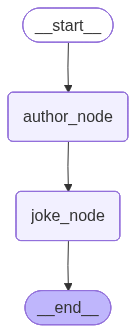

In [18]:
from typing import TypedDict
from typing_extensions import NotRequired
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from langchain_community.chat_models import ChatTongyi

# 构建阿里云百炼大模型客户端
# 构建阿里云百炼大模型客户端
llm = ChatTongyi(
    api_key="sk-0e1e78cdb7034f8babefc27516eaedf2",
    base_url="https://api.aliyun.com/v1",
    model="qwen-max"
)

class State(TypedDict):
    author: NotRequired[str]
    joke: NotRequired[str]

def author_node(state: State):
    prompt = "帮我推荐一位受人们欢迎的作家。只需要给出作家的名字即可。"
    author = llm.invoke(prompt)
    return {"author": author}

def joke_node(state: State):
    prompt = f"用作家:{state['author']}的风格,写一个100字以内的笑话"
    joke = llm.invoke(prompt)
    return {"joke": joke}

builder = StateGraph(State)
builder.add_node("author_node", author_node)
builder.add_node("joke_node", joke_node)

builder.add_edge(START, "author_node")
builder.add_edge("author_node", "joke_node")
builder.add_edge("joke_node", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [19]:
# 正常执行一个图
import uuid

config = {
    "configurable": {
        "thread_id": uuid.uuid4(),
    }
}

state = graph.invoke({}, config)
print(state["author"])
print()
print(state["joke"])

content='余华' additional_kwargs={} response_metadata={'model_name': 'qwen-max', 'finish_reason': 'stop', 'request_id': '717e74a1-bbf1-94e8-91a3-1a3ac0b0c8ae', 'token_usage': {'input_tokens': 23, 'output_tokens': 2, 'prompt_tokens_details': {'cached_tokens': 0}, 'total_tokens': 25}} id='lc_run--019e548a-a875-7193-83e3-e9284c71c02a-0' tool_calls=[] invalid_tool_calls=[]

content='在一个小镇上，有个人特别爱吹牛，他说自己能把任何东西吹得飞起来。一天，他对着一块大石头吹气，结果当然是纹丝不动。旁边的人笑着说：“你这本事，连余华小说里的悲惨都吹不走啊。”' additional_kwargs={} response_metadata={'model_name': 'qwen-max', 'finish_reason': 'stop', 'request_id': '37e8c2bf-0234-92f7-acc8-bd882cafb3b1', 'token_usage': {'input_tokens': 175, 'output_tokens': 58, 'prompt_tokens_details': {'cached_tokens': 0}, 'total_tokens': 233}} id='lc_run--019e548a-af78-7bd1-b2cc-a4d2ec704875-0' tool_calls=[] invalid_tool_calls=[]


In [20]:
# 查看所有checkpoint检查点
states = list(graph.get_state_history(config))

for state in states:
    print(state.next)
    print(state.config["configurable"]["checkpoint_id"])
    print()

()
1f156988-2d5f-6725-8002-b5ad885eb99d

('joke_node',)
1f156987-ce75-6e1a-8001-51c5c3031271

('author_node',)
1f156987-bd53-6532-8000-b7cfbe783543

('__start__',)
1f156987-bd4b-6fdc-bfff-1e74832561e3



In [21]:
# 选定某一个检查点。这里选择author_node，让大模型重新推荐作家
selected_state = states[1]
print(selected_state.next)
print(selected_state.values)

('joke_node',)
{'author': AIMessage(content='余华', additional_kwargs={}, response_metadata={'model_name': 'qwen-max', 'finish_reason': 'stop', 'request_id': '717e74a1-bbf1-94e8-91a3-1a3ac0b0c8ae', 'token_usage': {'input_tokens': 23, 'output_tokens': 2, 'prompt_tokens_details': {'cached_tokens': 0}, 'total_tokens': 25}}, id='lc_run--019e548a-a875-7193-83e3-e9284c71c02a-0', tool_calls=[], invalid_tool_calls=[])}


In [22]:
# 为了后面的重演，更新state。可选步骤：
new_config = graph.update_state(selected_state.config, values={"author": "郭德纲"})
print(new_config)

{'configurable': {'thread_id': '12d84b1c-afdc-4980-b5b0-fc46f033e4b7', 'checkpoint_ns': '', 'checkpoint_id': '1f15698a-231c-6054-8002-95e15424a6e9'}}


In [23]:
# 接下来，指定thread_id和checkpoint_id，进行重演
# 使用更新后的config继续执行
graph.invoke(None, new_config)

{'author': '郭德纲',
 'joke': AIMessage(content='话说有一回，于谦去超市买菜，挑来挑去拿不定主意。旁边一大妈见状，热心地说：“小伙子，别犹豫了，这菜跟人一样，看着顺眼就得了。”于谦一听乐了：“那大妈您看我，是不是特顺眼？”大妈愣了一下，笑着说：“你啊，长得挺喜庆，适合过年时候摆家里！”', additional_kwargs={}, response_metadata={'model_name': 'qwen-max', 'finish_reason': 'stop', 'request_id': '03e4ffc0-4dd5-9516-a6b8-1403341ef1ec', 'token_usage': {'input_tokens': 26, 'output_tokens': 83, 'prompt_tokens_details': {'cached_tokens': 0}, 'total_tokens': 109}}, id='lc_run--019e548c-5347-7220-83cf-63ebcb54ba30-0', tool_calls=[], invalid_tool_calls=[])}

# 五、多智能体架构

可以看到，在LangChain体系中，LangChain主要集成了和大语言模型交互的能力，而LangGraph主要实现了复杂的流程调度。将这两个能力结合起来，一个强大的多智能体构建框架就已经成型了。

接下来，我们就用LangGraph来实现一个非常典型的多智能体架构，作为一个完整的案例。

这个机器人可以通过一个supervisor节点，对用户的输入进行分类，然后根据分类结果，选择不同的agent节点进行处理。接下来每个Agent节点，都可以选择不同的工具进行处理，最后将处理结果汇总，返回给supervisor节点。supervisor节点再将结果返回给用户。



![](./figures/8.png)

**架构说明：**
- **SuperVisor**：负责接收Client请求，对消息进行分类，调度到不同的Agent
- **路线规划助手**：LLM + Tools + MCP（路线规划MCP服务）
- **对对联助手**：LLM + RAG（VectorStore + VectorLoader）
- **笑话助手**：直接与大模型交互
- **其他问题**：拒绝回答

在实现时，为了能够更综合的演练这么长时间的学习效果，我们对各个智能体的功能进行了一些设计，从而让这个小案例不再只是一个简单的Demo。

- 其他问题，只添加一个简单的响应结果。
- 笑话助手，直接与大模型交互获得一个结果。
- 对对联助手，从向量数据库中获取补充的资料，实现一个典型的RAG流程。
- 路线规划助手，则需要调度外部的MCP服务，获取补充信息。

这个案例，即作为LangGraph系列的总结演练，也作为一个典型的多智能体案例，强烈建议你，自己动手试试实现一个。在这个案例中，LangGraph更多的帮助我们来梳理各个智能体之间如何协调。而具体实现时，可以更多的借鉴LangChain的能力。还有，不要忘了，LangGraph还提供了很多开发过程中可以用到的工具，比如自定义流式输出、Time-travel时间重演等，都可以在这个案例中逐步尝试。


# 总结

从LangGraph的整个演练过程可以看到，LangGraph的核心是Graph。Graph其实是一个与大模型没有直接关联的，处理复杂任务的流程结构。LangGraph或者说整个LangChain系列，其实是将传统的软件构建经验与大语言模型的能力进行结合，从而进一步打造出强大的智能体，解决更多实际的复杂问题。这也进一步验证了，大语言模型未来的发展方向，一定是需要与传统应用相结合，这样才能更好的发挥大语言模型的价值。而这，或许是LangChain系列最核心的价值所在。